In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load data
Data = pd.read_excel(r'F:\WL_Q_SW17_1_Baral_MLP.xlsx')
X = Data[['WL']].values.astype(np.float32)
y = Data['Q'].values.astype(np.float32).reshape(-1, 1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

# Create datasets and dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Using device: cpu


# Simple Model

In [8]:
class SimpleANN(nn.Module):
    def __init__(self, input_size=1, hidden_sizes=[64, 32, 16]):
        super(SimpleANN, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Initialize model
model = SimpleANN().to(device)
print(model)

SimpleANN(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
  )
)


# Deeper ANN with Batch Normalization and Skip Connections

In [25]:
class AdvancedANN(nn.Module):
    def __init__(self, input_size=1, hidden_sizes=[128, 256, 128, 64, 32]):
        super(AdvancedANN, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # Encoder path
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(0.3)
            ])
            prev_size = hidden_size
        
        # Additional processing layers
        self.feature_extractor = nn.Sequential(*layers)
        
        # Decoder/Output layers with residual connections concept
        self.fc1 = nn.Linear(prev_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        
        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # Feature extraction
        x = self.feature_extractor(x)
        
        # Dense layers with skip-like connections
        identity = x
        
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        
        return x
model = AdvancedANN()

In [27]:
def train_model(model, train_loader, test_loader, epochs=500, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                     factor=0.5, patience=20)
    
    train_losses = []
    test_losses = []
    best_test_loss = float('inf')
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation
        model.eval()
        test_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                test_loss += loss.item()
        
        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)
        
        # Learning rate scheduling
        scheduler.step(avg_test_loss)
        
        # Save best model
        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            torch.save(model.state_dict(), 'best_model.pth')
        
        if (epoch + 1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}')
    
    return train_losses, test_losses

In [28]:
def evaluate_model(model, test_loader, scaler_y):
    model.eval()
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(batch_y.numpy())
    
    # Inverse transform
    predictions = scaler_y.inverse_transform(np.array(predictions))
    actuals = scaler_y.inverse_transform(np.array(actuals))
    
    return predictions, actuals

def plot_results(train_losses, test_losses, predictions, actuals):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Loss curves
    axes[0, 0].plot(train_losses, label='Training Loss')
    axes[0, 0].plot(test_losses, label='Validation Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # Actual vs Predicted
    axes[0, 1].scatter(actuals, predictions, alpha=0.6)
    min_val = min(min(actuals), min(predictions))
    max_val = max(max(actuals), max(predictions))
    axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Fit')
    axes[0, 1].set_xlabel('Actual Q')
    axes[0, 1].set_ylabel('Predicted Q')
    axes[0, 1].set_title('Actual vs Predicted Values')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # Residuals
    residuals = predictions - actuals
    axes[1, 0].scatter(actuals, residuals, alpha=0.6)
    axes[1, 0].axhline(y=0, color='r', linestyle='--')
    axes[1, 0].set_xlabel('Actual Q')
    axes[1, 0].set_ylabel('Residuals')
    axes[1, 0].set_title('Residual Plot')
    axes[1, 0].grid(True)
    
    # Distribution of errors
    axes[1, 1].hist(residuals, bins=20, edgecolor='black')
    axes[1, 1].set_xlabel('Prediction Error')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Error Distribution')
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()

Epoch [50/500], Train Loss: 0.5625, Test Loss: 0.5804
Epoch [100/500], Train Loss: 0.5297, Test Loss: 0.5859
Epoch [150/500], Train Loss: 0.5408, Test Loss: 0.5758
Epoch [200/500], Train Loss: 0.4950, Test Loss: 0.5365
Epoch [250/500], Train Loss: 0.5515, Test Loss: 0.5751
Epoch [300/500], Train Loss: 0.4997, Test Loss: 0.5579
Epoch [350/500], Train Loss: 0.5187, Test Loss: 0.5500
Epoch [400/500], Train Loss: 0.5169, Test Loss: 0.5567
Epoch [450/500], Train Loss: 0.5792, Test Loss: 0.5537
Epoch [500/500], Train Loss: 0.5139, Test Loss: 0.5657

Model Performance Metrics:
MAE: 27.57
RMSE: 35.78
R² Score: 0.5242


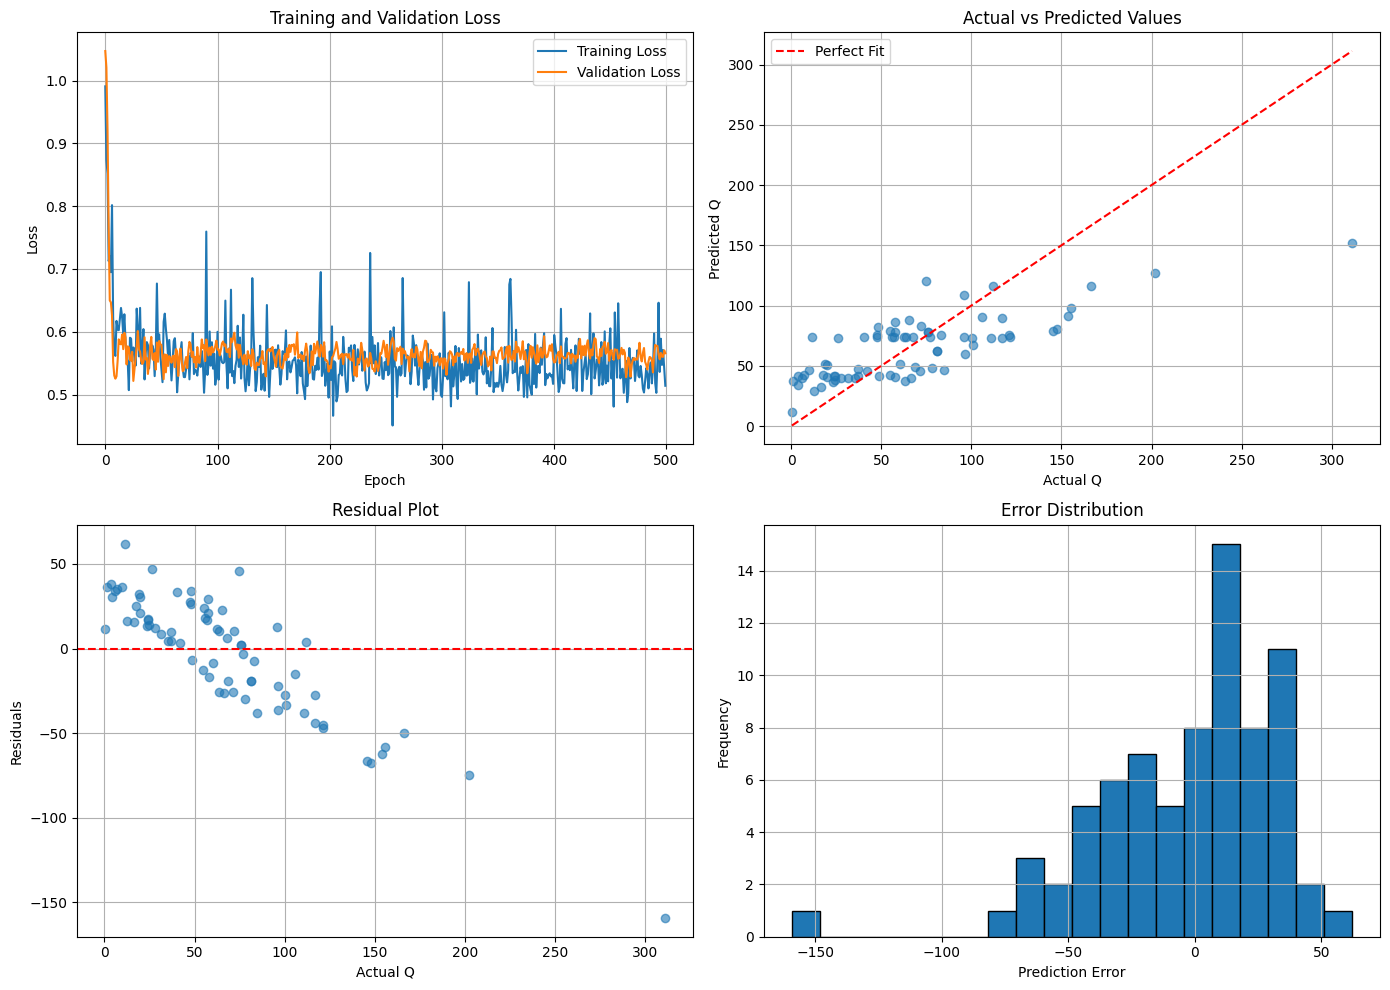

In [29]:
# Train the model
train_losses, test_losses = train_model(
    model, train_loader, test_loader, 
    epochs=500, lr=0.001
)

# Load best model
model.load_state_dict(torch.load('best_model.pth'))

# Evaluate
predictions, actuals = evaluate_model(model, test_loader, scaler_y)

# Calculate metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(actuals, predictions)

print(f"\nModel Performance Metrics:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# Plot results
plot_results(train_losses, test_losses, predictions, actuals)

# Prediction With 

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\rbe\AppData\Local\Temp\ipykernel_19476\1110447354.py:1: SyntaxWarning: invalid escape sequence '\P'
  Observed_Q_2020 = pd.read_excel('F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\Observed Q 2020 BWDB.xlsx')
C:\Users\rbe\AppData\Local\Temp\ipykernel_19476\1110447354.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')


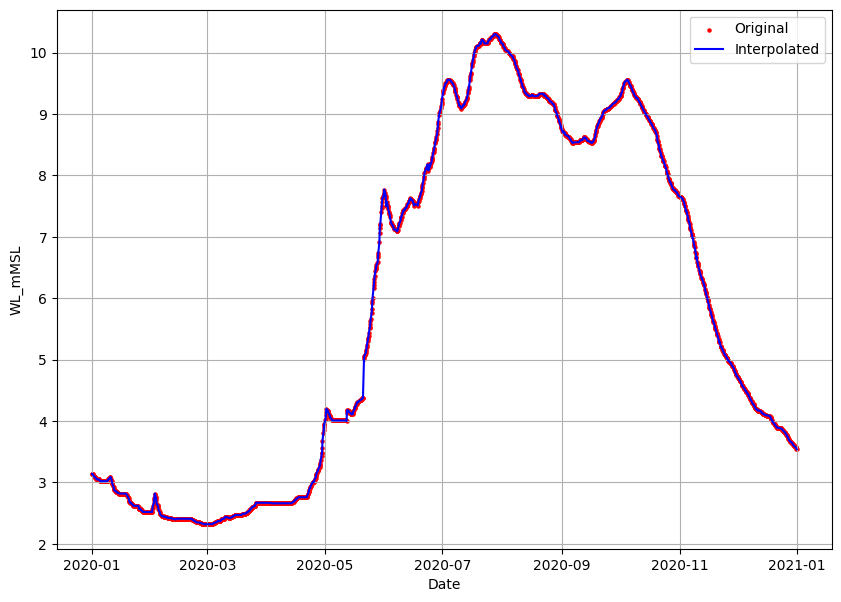

In [30]:
Observed_Q_2020 = pd.read_excel('F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\Observed Q 2020 BWDB.xlsx')
Observed_Q_2020['Date'] = pd.to_datetime(Observed_Q_2020['Date'],dayfirst=True)

import pandas as pd

file_path = r'F:\P-529990 Joydeppur Iswardi Double Rail Line\Model For B#23 Boral River\Boundary\WL_Data_All_Flood_Event_Year.xlsx'

# Read all sheets into a dictionary
dfs = pd.read_excel(file_path, sheet_name=None)

# Convert Date column in each sheet
for name, df in dfs.items():
    df['Date'] = pd.to_datetime(df['Date'])

# Access individual sheets
WL_1988_100yr = dfs['1988 100yr']
WL_2017_50yr  = dfs['2017 50yr']
WL_2004_25yr  = dfs['2004 25yr']
WL_2008_2_33yr = dfs['2008 2.33yr']
WL_2020_Clib = dfs['Calibration 2020']

WL_2020_Clib['Date'] = pd.to_datetime(WL_2020_Clib['Date'])
df = WL_2020_Clib.copy()

# Create interpolated column (same initial values)
df['Interpolated_WL_mMSL'] = df['WL_mMSL']

# Set Date as index
df.set_index('Date', inplace=True)

# Full hourly range
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')
df_full = df.reindex(full_range)

# Interpolate ONLY the interpolated column
df_full['Interpolated_WL_mMSL'] = df_full['Interpolated_WL_mMSL'].interpolate(method='linear')

# Reset index
df_full.reset_index(inplace=True)
df_full.rename(columns={'index': 'Date'}, inplace=True)

df_full.head()

plt.figure(figsize=(10, 7))

# Original data (no interpolation)
plt.scatter(
    WL_2020_Clib['Date'],
    WL_2020_Clib['WL_mMSL'],
    label='Original',
    s=5,
    color='red'
)

# Interpolated data
plt.plot(
    df_full['Date'],
    df_full['Interpolated_WL_mMSL'],
    label='Interpolated',
    color='blue'
)

plt.legend()
plt.grid()
plt.xlabel('Date')
plt.ylabel('WL_mMSL')
plt.show()


In [31]:
def predict_wl_to_q(model, wl_values, scaler_X, scaler_y):
    """
    Predict Q from WL values
    """
    model.eval()
    wl_array = np.array(wl_values).reshape(-1, 1).astype(np.float32)
    wl_scaled = scaler_X.transform(wl_array)
    wl_tensor = torch.FloatTensor(wl_scaled).to(device)
    
    with torch.no_grad():
        q_scaled = model(wl_tensor).cpu().numpy()
    
    q_values = scaler_y.inverse_transform(q_scaled)
    return q_values.flatten()

# Example usage
new_wl_values = [8.0, 10.5, 11.0, 12.5]
predicted_q = predict_wl_to_q(model, new_wl_values, scaler_X, scaler_y)

for wl, q in zip(new_wl_values, predicted_q):
    print(f"WL: {wl:.2f} → Predicted Q: {q:.2f}")

WL: 8.00 → Predicted Q: 73.99
WL: 10.50 → Predicted Q: 96.26
WL: 11.00 → Predicted Q: 110.91
WL: 12.50 → Predicted Q: 163.66


                 Date  WL_mMSL  Predicted_Q
0 2020-01-01 06:00:00     3.14    29.624949
1 2020-01-01 09:00:00     3.14    29.624949
2 2020-01-01 12:00:00     3.13    29.509924
3 2020-01-01 15:00:00     3.13    29.509924
4 2020-01-01 18:00:00     3.12    29.393759
5 2020-01-02 06:00:00     3.10    29.161226
6 2020-01-02 09:00:00     3.09    29.044958
7 2020-01-02 12:00:00     3.09    29.044958
8 2020-01-02 15:00:00     3.09    29.044958
9 2020-01-02 18:00:00     3.09    29.044958


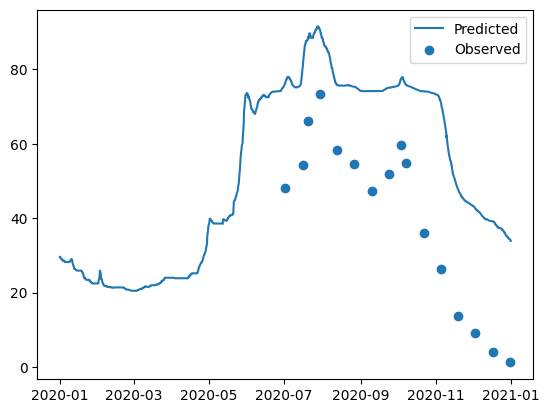

In [32]:
predicted_q = predict_wl_to_q(model, WL_2020_Clib['WL_mMSL'], scaler_X, scaler_y)
# Add the predicted Q values as a new column
WL_2020_Clib['Predicted_Q'] = predicted_q

# Now you can view the dataframe with the new column
print(WL_2020_Clib.head(10))

plt.plot(WL_2020_Clib['Date'], WL_2020_Clib['Predicted_Q'], label = 'Predicted')
plt.scatter(Observed_Q_2020['Date'], Observed_Q_2020['Observed_Q'], label = 'Observed')
plt.legend()
plt.show()